# EdgeTwin AI — Predictive Maintenance
## 02_Feature_Engineering.ipynb

**Step 4: Feature Engineering**

Input: `predictive_maintenance_cleaned.csv` (output of `01_Data_Understanding.ipynb`)

This notebook selects meaningful sensor features, removes irrelevant columns, analyzes feature
importance and correlation, engineers new domain-driven features, and prepares the final feature
set for the Data Transformation phase.


---
## 0. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

RANDOM_STATE = 42


---
## 1. Load Cleaned Dataset

In [2]:
df = pd.read_csv('predictive_maintenance_cleaned.csv', parse_dates=['Timestamp'])

print(f"Cleaned dataset loaded. Shape: {df.shape}")
df.head()


Cleaned dataset loaded. Shape: (9893, 15)


,Machine_ID,Timestamp,Machine_Type,Air_Temperature_C,Process_Temperature_C,Rotational_Speed_RPM,Torque_Nm,Vibration_mm_s,Pressure_bar,Current_A,Voltage_V,Tool_Wear_Min,Operating_Hours,Failure_Type,Machine_Failure
0,PMP-1016,2024-03-02 10:08:00,Pump,28.68,39.66,1544.0,42.00,3.258,6.80,14.63,419.1,41.8,11447.1,No Failure,0
1,CNC-1032,2024-03-19 15:24:00,Cnc_Machine,26.34,36.74,1866.0,49.10,3.157,7.24,16.73,407.5,98.6,13154.1,No Failure,0
2,CMP-1001,2024-03-02 06:30:00,Compressor,19.54,29.82,1893.0,35.47,2.760,7.34,11.43,408.0,165.2,14200.3,No Failure,0
3,PMP-1019,2024-05-04 12:01:00,Pump,24.93,33.20,1500.0,25.58,2.662,4.73,14.61,429.7,222.5,4206.0,No Failure,0
4,CMP-1042,2024-01-17 06:18:00,Compressor,25.29,33.44,1245.0,38.87,3.936,6.47,13.85,415.2,62.7,13340.1,No Failure,0


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9893 entries, 0 to 9892
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Machine_ID             9893 non-null   object        
 1   Timestamp              9893 non-null   datetime64[ns]
 2   Machine_Type           9893 non-null   object        
 3   Air_Temperature_C      9893 non-null   float64       
 4   Process_Temperature_C  9893 non-null   float64       
 5   Rotational_Speed_RPM   9893 non-null   float64       
 6   Torque_Nm              9893 non-null   float64       
 7   Vibration_mm_s         9893 non-null   float64       
 8   Pressure_bar           9893 non-null   float64       
 9   Current_A              9893 non-null   float64       
 10  Voltage_V              9893 non-null   float64       
 11  Tool_Wear_Min          9893 non-null   float64       
 12  Operating_Hours        9893 non-null   float64       
 13  Fai

---
## 2. Selecting Useful Sensor Parameters

`Machine_ID` and `Timestamp` are identifiers/metadata used for traceability and time-based grouping,
but they are not physically meaningful sensor readings, so they will not be used as direct model
input features. `Failure_Type` is a descriptive label of *which* failure occurred and is kept aside
for reporting/analysis, while `Machine_Failure` is the actual binary target used for prediction.


In [4]:
# Identifier / metadata columns — retained for traceability, not used as model features
id_columns = ['Machine_ID', 'Timestamp']

# Core sensor features considered useful for predicting machine failure
core_sensor_features = [
    'Machine_Type',
    'Air_Temperature_C',
    'Process_Temperature_C',
    'Rotational_Speed_RPM',
    'Torque_Nm',
    'Vibration_mm_s',
    'Pressure_bar',
    'Current_A',
    'Voltage_V',
    'Tool_Wear_Min',
    'Operating_Hours',
]

# Target variable and descriptive label
target_column = 'Machine_Failure'
label_column = 'Failure_Type'

print("ID/metadata columns:", id_columns)
print("\nCore sensor features:", core_sensor_features)
print("\nTarget column:", target_column)


ID/metadata columns: ['Machine_ID', 'Timestamp']

Core sensor features: ['Machine_Type', 'Air_Temperature_C', 'Process_Temperature_C', 'Rotational_Speed_RPM', 'Torque_Nm', 'Vibration_mm_s', 'Pressure_bar', 'Current_A', 'Voltage_V', 'Tool_Wear_Min', 'Operating_Hours']

Target column: Machine_Failure


---
## 3. Removing Irrelevant Columns

Administrative columns such as `Sensor_Batch_Code` and `Checksum_Flag` were already removed during
Data Cleaning (`01_Data_Understanding.ipynb`). Here we confirm no leftover irrelevant columns remain,
and build a clean working DataFrame limited to ID columns, core sensor features, and target/label
columns.


In [5]:
expected_columns = id_columns + core_sensor_features + [label_column, target_column]
unexpected_columns = [c for c in df.columns if c not in expected_columns]

print("Unexpected / irrelevant columns still present:", unexpected_columns)

# Keep only the relevant columns, in a clean order
df = df[expected_columns].copy()
print(f"\nShape after keeping only relevant columns: {df.shape}")
df.head()


Unexpected / irrelevant columns still present: []

Shape after keeping only relevant columns: (9893, 15)


,Machine_ID,Timestamp,Machine_Type,Air_Temperature_C,Process_Temperature_C,Rotational_Speed_RPM,Torque_Nm,Vibration_mm_s,Pressure_bar,Current_A,Voltage_V,Tool_Wear_Min,Operating_Hours,Failure_Type,Machine_Failure
0,PMP-1016,2024-03-02 10:08:00,Pump,28.68,39.66,1544.0,42.00,3.258,6.80,14.63,419.1,41.8,11447.1,No Failure,0
1,CNC-1032,2024-03-19 15:24:00,Cnc_Machine,26.34,36.74,1866.0,49.10,3.157,7.24,16.73,407.5,98.6,13154.1,No Failure,0
2,CMP-1001,2024-03-02 06:30:00,Compressor,19.54,29.82,1893.0,35.47,2.760,7.34,11.43,408.0,165.2,14200.3,No Failure,0
3,PMP-1019,2024-05-04 12:01:00,Pump,24.93,33.20,1500.0,25.58,2.662,4.73,14.61,429.7,222.5,4206.0,No Failure,0
4,CMP-1042,2024-01-17 06:18:00,Compressor,25.29,33.44,1245.0,38.87,3.936,6.47,13.85,415.2,62.7,13340.1,No Failure,0


---
## 4. Feature Importance Analysis

A quick Random Forest model is trained purely for the purpose of ranking feature importance
(this is **not** the final model — model training/evaluation happens in a later notebook).
`Machine_Type` is temporarily one-hot encoded here only to allow the importance model to run;
the actual encoding strategy is finalized in `03_Data_Transformation.ipynb`.


In [6]:
# Temporary encoding purely for importance ranking
fi_df = pd.get_dummies(df[core_sensor_features], columns=['Machine_Type'], drop_first=True)
fi_target = df[target_column]

X_train_fi, X_test_fi, y_train_fi, y_test_fi = train_test_split(
    fi_df, fi_target, test_size=0.2, random_state=RANDOM_STATE, stratify=fi_target
)

rf_importance_model = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf_importance_model.fit(X_train_fi, y_train_fi)

importance_df = pd.DataFrame({
    'Feature': fi_df.columns,
    'Importance': rf_importance_model.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

importance_df


,Feature,Importance
0,Process_Temperature_C,0.195866
1,Vibration_mm_s,0.165641
2,Tool_Wear_Min,0.157688
3,Voltage_V,0.135988
4,Air_Temperature_C,0.110252
5,Torque_Nm,0.106814
6,Current_A,0.042511
7,Pressure_bar,0.029142
8,Rotational_Speed_RPM,0.023839
9,Operating_Hours,0.021849


C:\Users\jamee\AppData\Local\Temp\ipykernel_16120\3825759822.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


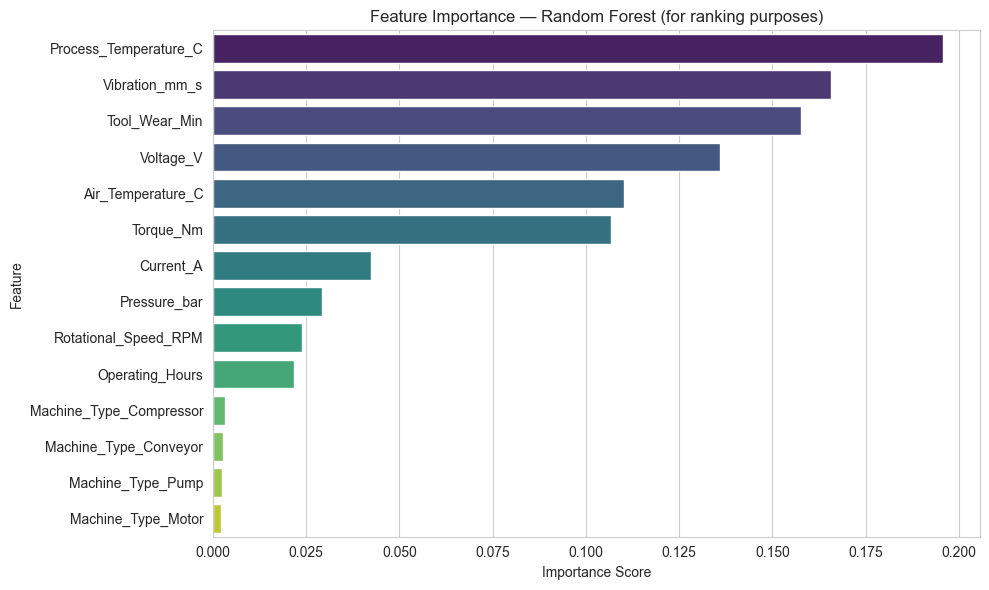

In [7]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Feature Importance — Random Forest (for ranking purposes)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


---
## 5. Correlation-Based Feature Selection

A correlation heatmap is used to detect multicollinearity among numerical sensor features
(e.g. `Air_Temperature_C` vs `Process_Temperature_C`). Highly correlated pairs (|correlation| > 0.85)
are flagged for review.


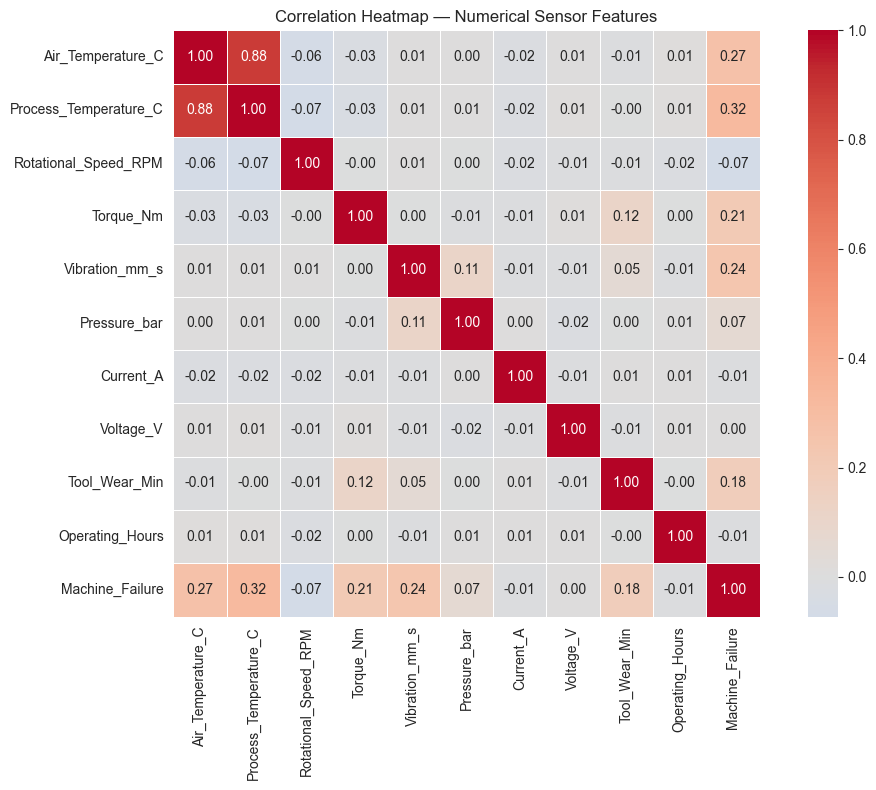

In [8]:
numerical_features = [c for c in core_sensor_features if c != 'Machine_Type']

corr_matrix = df[numerical_features + [target_column]].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True)
plt.title('Correlation Heatmap — Numerical Sensor Features')
plt.tight_layout()
plt.show()


In [9]:
# Identify highly correlated feature pairs (excluding the diagonal and the target)
threshold = 0.85
corr_pairs = corr_matrix.drop(index=target_column, columns=target_column).abs()

high_corr_pairs = []
for i in range(len(corr_pairs.columns)):
    for j in range(i + 1, len(corr_pairs.columns)):
        val = corr_pairs.iloc[i, j]
        if val > threshold:
            high_corr_pairs.append((corr_pairs.columns[i], corr_pairs.columns[j], round(val, 3)))

high_corr_df = pd.DataFrame(high_corr_pairs, columns=['Feature_1', 'Feature_2', 'Correlation'])
print(f"Highly correlated pairs (|corr| > {threshold}):")
high_corr_df if len(high_corr_df) > 0 else "None found — no redundant features to drop."


Highly correlated pairs (|corr| > 0.85):


,Feature_1,Feature_2,Correlation
0,Air_Temperature_C,Process_Temperature_C,0.881


In [10]:
# Correlation of each numerical feature with the target (Machine_Failure)
target_corr = corr_matrix[target_column].drop(target_column).sort_values(key=abs, ascending=False)
print("Correlation of each feature with Machine_Failure:")
target_corr


Correlation of each feature with Machine_Failure:


Process_Temperature_C    0.317279
Air_Temperature_C        0.271625
Vibration_mm_s           0.235443
Torque_Nm                0.205624
Tool_Wear_Min            0.177807
Rotational_Speed_RPM    -0.072573
Pressure_bar             0.065640
Operating_Hours         -0.010352
Current_A               -0.006582
Voltage_V                0.004291
Name: Machine_Failure, dtype: float64

---
## 6. Domain Knowledge — Creating Derived Features

Using mechanical and electrical engineering principles, new features are derived that better
capture the physical conditions leading to specific failure types:

- **Temperature_Difference** = `Process_Temperature_C` − `Air_Temperature_C` → low differences relative to expected operating delta indicate poor heat dissipation
- **Power_Approx** = `Voltage_V` × `Current_A` (approximate electrical power draw, in Watts) → abnormal power draw indicates electrical/power failure
- **Wear_Rate** = `Tool_Wear_Min` / `Operating_Hours` → high wear rate indicates accelerated tool degradation (Tool Wear Failure risk)
- **Torque_per_RPM** = `Torque_Nm` / `Rotational_Speed_RPM` → captures mechanical load relative to speed, relevant to Overstrain Failure


In [11]:
df_fe = df.copy()

# Temperature Difference
df_fe['Temperature_Difference'] = df_fe['Process_Temperature_C'] - df_fe['Air_Temperature_C']

# Approximate Electrical Power (Watts)
df_fe['Power_Approx'] = df_fe['Voltage_V'] * df_fe['Current_A']

# Tool Wear Rate (minutes of wear per operating hour); avoid divide-by-zero
df_fe['Wear_Rate'] = df_fe['Tool_Wear_Min'] / df_fe['Operating_Hours'].replace(0, np.nan)
df_fe['Wear_Rate'] = df_fe['Wear_Rate'].fillna(df_fe['Wear_Rate'].median())

# Torque per RPM (mechanical load relative to speed); avoid divide-by-zero
df_fe['Torque_per_RPM'] = df_fe['Torque_Nm'] / df_fe['Rotational_Speed_RPM'].replace(0, np.nan)
df_fe['Torque_per_RPM'] = df_fe['Torque_per_RPM'].fillna(df_fe['Torque_per_RPM'].median())

derived_features = ['Temperature_Difference', 'Power_Approx', 'Wear_Rate', 'Torque_per_RPM']
df_fe[derived_features].describe().T


,count,mean,std,min,25%,50%,75%,max
Temperature_Difference,9893.0,10.070820,1.629077,-2.970000,9.190000,9.990000,10.840000,27.630000
Power_Approx,9893.0,4984.822083,1483.053613,0.000000,4046.707000,4985.351000,5893.923000,12790.706000
Wear_Rate,9893.0,0.069047,1.161148,0.000000,0.007465,0.013736,0.025363,93.684211
Torque_per_RPM,9893.0,0.026857,0.007974,0.003131,0.021880,0.026236,0.031054,0.078927


C:\Users\jamee\AppData\Local\Temp\ipykernel_16120\4026834745.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Machine_Failure', y=feature, data=df_fe, ax=ax, palette='Set2')
C:\Users\jamee\AppData\Local\Temp\ipykernel_16120\4026834745.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Healthy (0)', 'Failed (1)'])
C:\Users\jamee\AppData\Local\Temp\ipykernel_16120\4026834745.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Machine_Failure', y=feature, data=df_fe, ax=ax, palette='Set2')
C:\Users\jamee\AppData\Local\Temp\ipykernel_16120\4026834745.py:5: UserWarning: set_ticklab

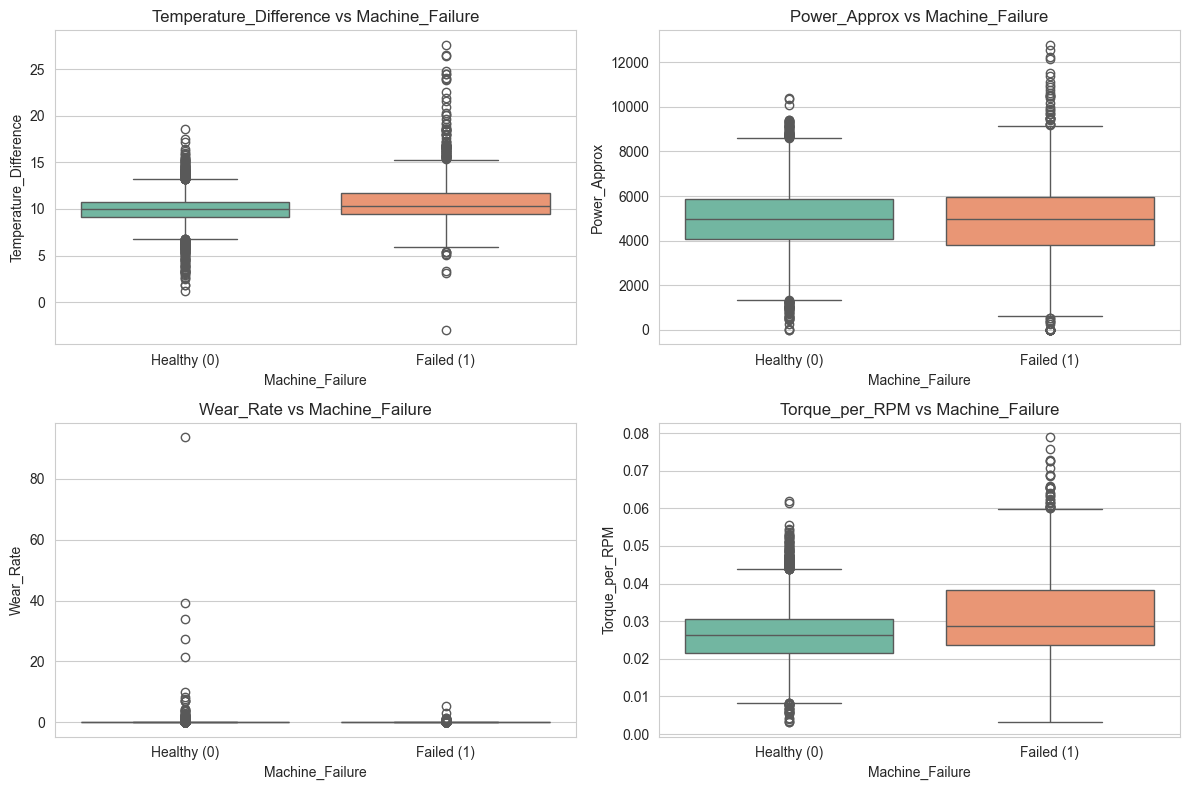

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, feature in zip(axes.flatten(), derived_features):
    sns.boxplot(x='Machine_Failure', y=feature, data=df_fe, ax=ax, palette='Set2')
    ax.set_title(f'{feature} vs Machine_Failure')
    ax.set_xticklabels(['Healthy (0)', 'Failed (1)'])
plt.tight_layout()
plt.show()


### 6.1 Correlation of Derived Features with Target

In [13]:
derived_corr = df_fe[derived_features + [target_column]].corr()[target_column].drop(target_column)
derived_corr.sort_values(key=abs, ascending=False)


Torque_per_RPM            0.217103
Temperature_Difference    0.195179
Power_Approx             -0.007275
Wear_Rate                -0.004135
Name: Machine_Failure, dtype: float64

---
## 7. Finalizing the Feature Set

The final feature set combines the core sensor features with the engineered derived features.
`Machine_ID` and `Timestamp` are retained in the saved file for traceability but are excluded from
the modeling feature list (`final_features`). This finalized dataset becomes the input to
`03_Data_Transformation.ipynb`.


In [14]:
final_features = core_sensor_features + derived_features

print(f"Total final features selected for modeling: {len(final_features)}")
for f in final_features:
    print(" -", f)


Total final features selected for modeling: 15
 - Machine_Type
 - Air_Temperature_C
 - Process_Temperature_C
 - Rotational_Speed_RPM
 - Torque_Nm
 - Vibration_mm_s
 - Pressure_bar
 - Current_A
 - Voltage_V
 - Tool_Wear_Min
 - Operating_Hours
 - Temperature_Difference
 - Power_Approx
 - Wear_Rate
 - Torque_per_RPM


In [15]:
# Build the final engineered dataset (ID columns retained for traceability, not for modeling)
final_columns = id_columns + final_features + [label_column, target_column]
df_engineered = df_fe[final_columns].copy()

print(f"Final engineered dataset shape: {df_engineered.shape}")
df_engineered.head()


Final engineered dataset shape: (9893, 19)


,Machine_ID,Timestamp,Machine_Type,Air_Temperature_C,Process_Temperature_C,Rotational_Speed_RPM,Torque_Nm,Vibration_mm_s,Pressure_bar,Current_A,Voltage_V,Tool_Wear_Min,Operating_Hours,Temperature_Difference,Power_Approx,Wear_Rate,Torque_per_RPM,Failure_Type,Machine_Failure
0,PMP-1016,2024-03-02 10:08:00,Pump,28.68,39.66,1544.0,42.00,3.258,6.80,14.63,419.1,41.8,11447.1,10.98,6131.433,0.003652,0.027202,No Failure,0
1,CNC-1032,2024-03-19 15:24:00,Cnc_Machine,26.34,36.74,1866.0,49.10,3.157,7.24,16.73,407.5,98.6,13154.1,10.40,6817.475,0.007496,0.026313,No Failure,0
2,CMP-1001,2024-03-02 06:30:00,Compressor,19.54,29.82,1893.0,35.47,2.760,7.34,11.43,408.0,165.2,14200.3,10.28,4663.440,0.011634,0.018737,No Failure,0
3,PMP-1019,2024-05-04 12:01:00,Pump,24.93,33.20,1500.0,25.58,2.662,4.73,14.61,429.7,222.5,4206.0,8.27,6277.917,0.052901,0.017053,No Failure,0
4,CMP-1042,2024-01-17 06:18:00,Compressor,25.29,33.44,1245.0,38.87,3.936,6.47,13.85,415.2,62.7,13340.1,8.15,5750.520,0.004700,0.031221,No Failure,0


## 8. Save Engineered Dataset

In [16]:
df_engineered.to_csv('predictive_maintenance_engineered.csv', index=False)
print("Engineered dataset saved as 'predictive_maintenance_engineered.csv'")
print(f"Final shape: {df_engineered.shape}")


Engineered dataset saved as 'predictive_maintenance_engineered.csv'
Final shape: (9893, 19)


---
## Summary

- Selected core sensor features relevant to predictive maintenance and separated them from ID/metadata columns.
- Confirmed no irrelevant/administrative columns remained after Data Cleaning.
- Ranked feature importance using a Random Forest model (for analysis purposes only).
- Performed correlation-based analysis to check for multicollinearity among sensor features.
- Applied domain knowledge to engineer four new features: `Temperature_Difference`, `Power_Approx`, `Wear_Rate`, and `Torque_per_RPM`.
- Finalized and saved the engineered feature set as `predictive_maintenance_engineered.csv`.

**Next Notebook:** `03_Data_Transformation.ipynb`
